In [8]:
import pandas as pd
import shap
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

import warnings
warnings.filterwarnings("ignore")


In [9]:
PROJECT_ROOT = Path.cwd().parent
model = joblib.load(PROJECT_ROOT / "models" / "apt_value_model.pkl")
train_df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "train.csv")

In [10]:
feature_cols = [c for c in train_df.columns if c not in ["price_per_area"]]
X_sample = train_df[feature_cols].sample(2000, random_state=42)

In [11]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

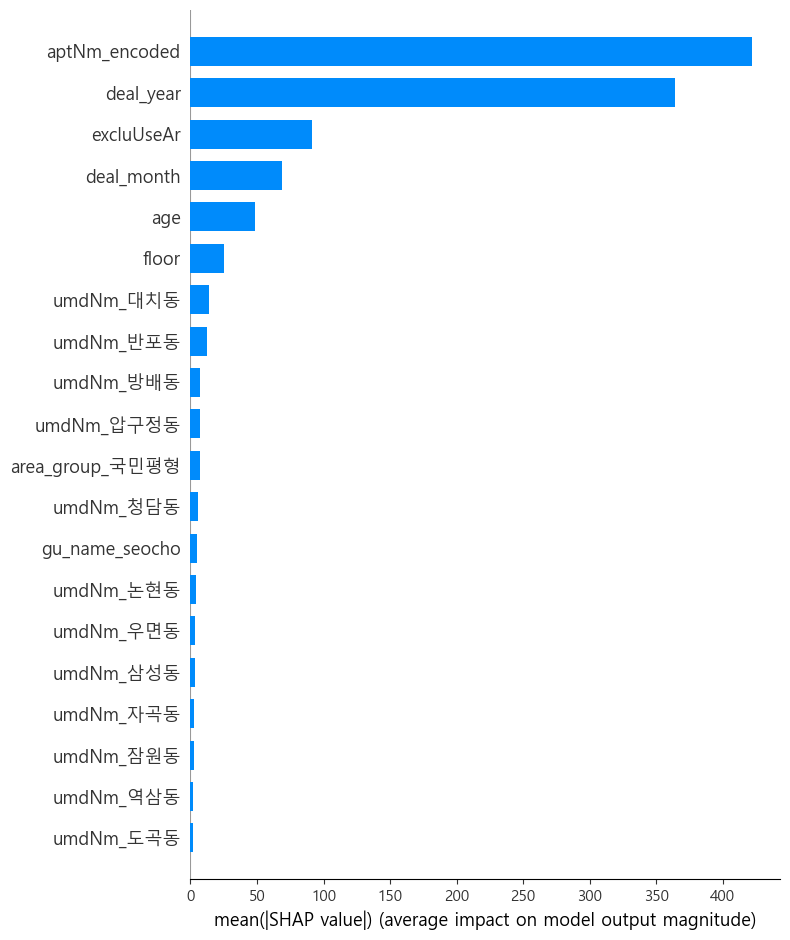

In [12]:
shap.summary_plot(shap_values, X_sample, plot_type="bar")

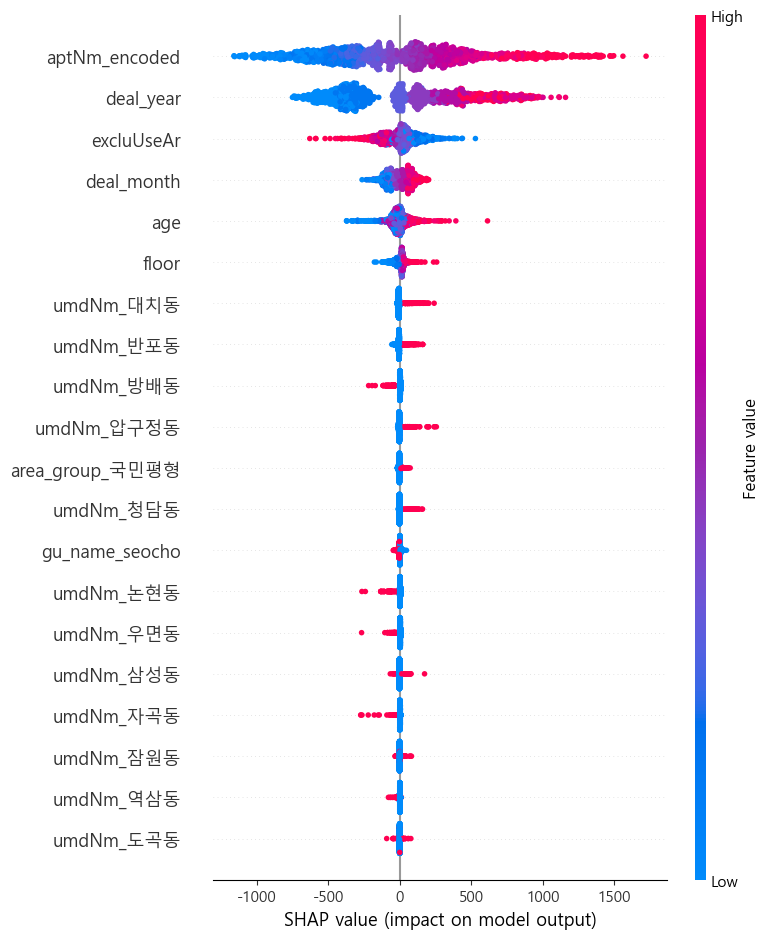

In [13]:
shap.summary_plot(shap_values, X_sample)

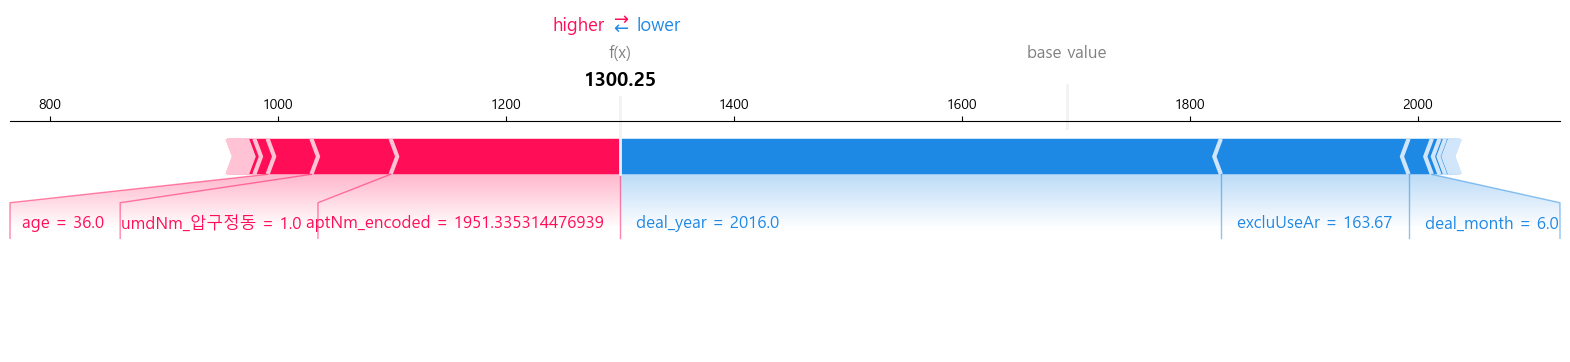

In [14]:
shap.initjs()

sample_idx = 0
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx],
    X_sample.iloc[sample_idx],
    matplotlib=True,
)